# Statistics of art in SWH RQ1

Distribution of dead/live origins and hosts.

The cell below streams `all_origins_final_version.json`, writes `dead_origins.json` (`metadata.live == false`) and `live_origins.json` (`metadata.live == true`), and extracts host counts into `hosts_dead_origins.json` / `hosts_live_origins.json`.

Host extraction strips any `scheme://` prefix and collapses every `*.googlecode.com` subdomain (e.g. `reponame.googlecode.com`) into a single `googlecode.com` host, which the old jq regex did not do.

In [1]:
import json

SRC = "all_origins_final_version.json"


def extract_host(origin):
    rest = origin.split("://", 1)[1] if "://" in origin else origin
    host = rest.split("/", 1)[0].split("@")[-1].split(":")[0]
    if host.endswith(".googlecode.com"):
        host = "googlecode.com"
    return host


def iter_origins(path):
    with open(path) as f:
        for line in f:
            line = line.strip().rstrip(",")
            if line in ("[", "]", ""):
                continue
            yield json.loads(line)


def write_hosts(counts, path):
    rows = sorted(
        ({"host": h, "count": c} for h, c in counts.items()),
        key=lambda r: r["count"],
        reverse=True,
    )
    with open(path, "w") as f:
        json.dump(rows, f, indent=2)


live_counts, dead_counts = {}, {}
with open("live_origins.json", "w") as lf, open("dead_origins.json", "w") as df:
    lf.write("[\n")
    df.write("[\n")
    first_live = first_dead = True
    for obj in iter_origins(SRC):
        is_live = obj["metadata"]["live"]
        host = extract_host(obj["origin"])
        if is_live:
            live_counts[host] = live_counts.get(host, 0) + 1
            lf.write(("" if first_live else ",\n") + json.dumps(obj))
            first_live = False
        else:
            dead_counts[host] = dead_counts.get(host, 0) + 1
            df.write(("" if first_dead else ",\n") + json.dumps(obj))
            first_dead = False
    lf.write("\n]\n")
    df.write("\n]\n")

write_hosts(live_counts, "hosts_live_origins.json")
write_hosts(dead_counts, "hosts_dead_origins.json")

print(f"live origins: {sum(live_counts.values()):,}, dead origins: {sum(dead_counts.values()):,}")


live origins: 1,533,502, dead origins: 84,666


In [2]:
# Sourceforge url format change

import json

PING_RESULTS = "sourceforge_ping_results.json"
LIVE_FILE = "hosts_live_origins.json"
DEAD_FILE = "hosts_dead_origins.json"

OLD_HOST = "git.code.sf.net"
NEW_HOST = "sourceforge.net"

with open(PING_RESULTS) as f:
    ping = json.load(f)

sf_live = sum(1 for r in ping if r["online"])
sf_dead = len(ping) - sf_live


def rewrite_sourceforge_host(path, sf_count):
    with open(path) as f:
        rows = json.load(f)
    # Only touch the SourceForge entries; leave every other host untouched.
    rows = [r for r in rows if r["host"] not in (OLD_HOST, NEW_HOST)]
    if sf_count > 0:
        rows.append({"host": NEW_HOST, "count": sf_count})
    rows.sort(key=lambda r: r["count"], reverse=True)
    with open(path, "w") as f:
        json.dump(rows, f, indent=2)


rewrite_sourceforge_host(LIVE_FILE, sf_live)
rewrite_sourceforge_host(DEAD_FILE, sf_dead)

print(f"{NEW_HOST}: {sf_live} live, {sf_dead} dead (was {OLD_HOST} with {len(ping)} dead)")

sourceforge.net: 92 live, 21 dead (was git.code.sf.net with 113 dead)


Total hosts: 9
Total occurrences: 1,618,168
('github.com', 1523852, 82298, 1606150), 99.3%
  dead/live ratio: 5.40%
('gitlab.com', 5563, 498, 6061), 0.4%
  dead/live ratio: 8.95%
('bitbucket.org', 2976, 209, 3185), 0.2%
  dead/live ratio: 7.02%
('googlecode.com', 0, 1114, 1114), 0.1%
('gitorious.org', 0, 326, 326), 0.0%
('codeberg.org', 242, 34, 276), 0.0%
  dead/live ratio: 14.05%
('framagit.org', 175, 0, 175), 0.0%
  dead/live ratio: 0.00%
('sourceforge.net', 92, 21, 113), 0.0%
  dead/live ratio: 22.83%
('158 others', 694, 74, 768), 0.0%
  dead/live ratio: 10.66%


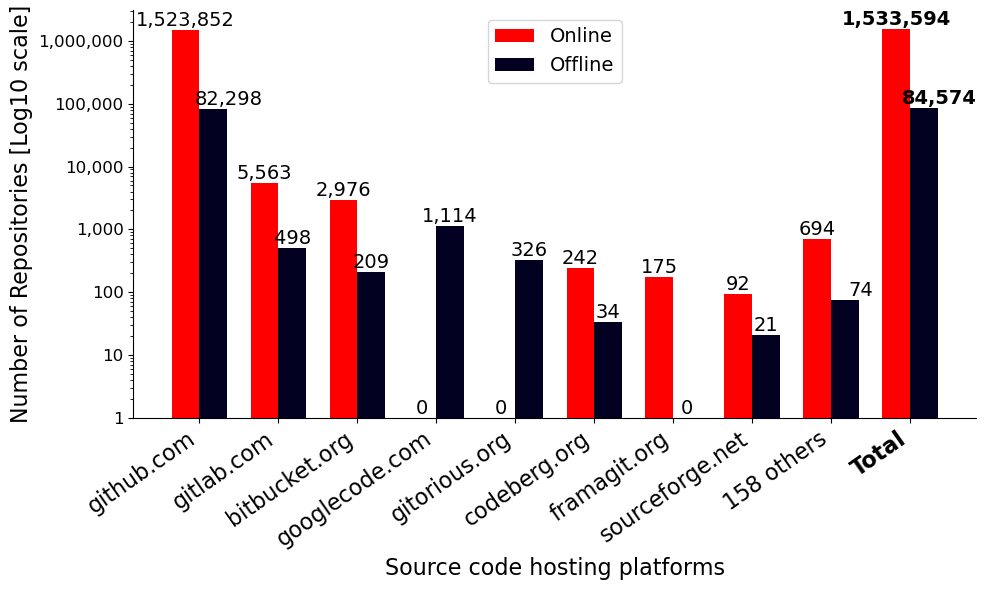

In [4]:
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

LIVE_FILE = "hosts_live_origins.json"
DEAD_FILE = "hosts_dead_origins.json"
MIN_OCCURRENCES = 100
OFFSET_LABELS = {"github.com"}


def load_counts(path):
    with open(path, "r") as f:
        data = json.load(f)

    counts = {}
    for item in data:
        host = item["host"]
        counts[host] = counts.get(host, 0) + item.get("count", 0)
    return counts

# Load datasets
live_counts = load_counts(LIVE_FILE)
dead_counts = load_counts(DEAD_FILE)

def build_rows(live_counts, dead_counts):
    hosts = set(live_counts) | set(dead_counts)
    rows = []
    others_live, others_dead, unique_others = 0, 0, 0

    for h in hosts:
        live = live_counts.get(h, 0)
        dead = dead_counts.get(h, 0)
        total = live + dead
        if total > MIN_OCCURRENCES:
            rows.append((h, live, dead, total))
        else:
            others_live += live
            others_dead += dead
            unique_others += 1

    rows.sort(key=lambda r: r[3], reverse=True)

    others_label = f"{unique_others:,} others"
    live_total = sum(r[1] for r in rows) + others_live
    dead_total = sum(r[2] for r in rows) + others_dead

    rows.append((others_label, others_live, others_dead, others_live + others_dead))
    rows.append(("Total", live_total, dead_total, live_total + dead_total))

    return rows, others_label


def print_summary(rows):
    data_rows = [r for r in rows if r[0] != "Total"]
    total = sum(r[3] for r in data_rows)
    print(f"Total hosts: {len(data_rows)}")
    print(f"Total occurrences: {total:,}")
    for row in data_rows:
        pct = row[3] / total * 100 if total else 0
        print(f"{row}, {pct:.1f}%")
        if row[1] > 0:
            print(f"  dead/live ratio: {row[2] / row[1] * 100:.2f}%")


def plot(rows, others_label):
    labels = [r[0] for r in rows]
    live_vals = [r[1] for r in rows]
    dead_vals = [r[2] for r in rows]

    epsilon = 1
    live_plot = [max(v, epsilon) for v in live_vals]
    dead_plot = [max(v, epsilon) for v in dead_vals]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.4), 6))

    ax.bar(x - width / 2, live_plot, width, label="Online", color="#FF0000")
    ax.bar(x + width / 2, dead_plot, width, label="Offline", color="#020122")

    need_offset = OFFSET_LABELS | {others_label, "Total"}
    for i, label in enumerate(labels):
        is_total = label == "Total"
        weight = "bold" if is_total else "normal"

        ax.text(
            x[i] - width / 2, live_plot[i], f"{live_vals[i]:,}",
            ha="center", va="bottom", fontsize=14, fontweight=weight,
        )
        offset = 0.2 if label in need_offset else 0.0
        ax.text(
            x[i] + width / 2 + offset, dead_plot[i], f"{dead_vals[i]:,}",
            ha="center", va="bottom", fontsize=14, fontweight=weight,
        )

    tick_weights = ["bold" if l == "Total" else "normal" for l in labels]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=16)
    for tick_label, w in zip(ax.get_xticklabels(), tick_weights):
        tick_label.set_fontweight(w)

    ax.set_yscale("log")
    ax.set_ylim(bottom=1)
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f"{int(y):,}" if y >= 1 else "")
    )
    ax.tick_params(axis="y", labelsize=12)

    ax.set_ylabel("Number of Repositories [Log10 scale]", fontsize=16)
    ax.set_xlabel("Source code hosting platforms", fontsize=16)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=14)
    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    live_counts = load_counts(LIVE_FILE)
    dead_counts = load_counts(DEAD_FILE)
    rows, others_label = build_rows(live_counts, dead_counts)
    print_summary(rows)
    plot(rows, others_label)


Hosts that are only have dead origins

```
jq -n '
  (input | map(.host)) as $live
  | (input | map(select(.host as $h | $live | index($h) | not)))
' hosts_live_origins.json hosts_dead_origins.json \
> hosts_only_dead.json
```

In [11]:
import json

SRC = "all_origins_final_version.json"


def extract_owner(origin):
    """Identify the repo owner/account from an origin URL.

    For hosts like github.com/<owner>/<repo> the owner is host + first path
    segment. For path-less origins (e.g. <project>.googlecode.com) the host
    already uniquely identifies the project, so it is used as-is.
    """
    rest = origin.split("://", 1)[1] if "://" in origin else origin
    parts = rest.split("/")
    host = parts[0].split("@")[-1].split(":")[0]
    if len(parts) > 1 and parts[1]:
        return f"{host}/{parts[1]}"
    return host


def iter_origins(path):
    with open(path) as f:
        for line in f:
            line = line.strip().rstrip(",")
            if line in ("[", "]", ""):
                continue
            yield json.loads(line)


owners_live, owners_dead = {}, {}
for obj in iter_origins(SRC):
    owner = extract_owner(obj["origin"])
    if obj["metadata"]["live"]:
        owners_live[owner] = owners_live.get(owner, 0) + 1
    else:
        owners_dead[owner] = owners_dead.get(owner, 0) + 1

only_dead_owners = {o: owners_dead[o] for o in owners_dead if o not in owners_live}
only_live_owners = {o: owners_live[o] for o in owners_live if o not in owners_dead}

def owners_to_json(owners_dict, path):
    rows = sorted(
        [{"owner": o, "count": c} for o, c in owners_dict.items()],
        key=lambda r: r["count"], reverse=True,
    )
    with open(path, "w") as f:
        json.dump(rows, f, indent=2)

owners_to_json(only_dead_owners, "owners_only_dead.json")
owners_to_json(only_live_owners, "owners_only_live.json")

print(f"Distinct owners total: {len(owners_live | owners_dead):,}")
print(f"Owners with >=1 live repo: {len(owners_live):,}")
print(f"Owners with >=1 dead repo: {len(owners_dead):,}")
print(f"Owners with ONLY dead repos: {len(only_dead_owners):,} -> owners_only_dead.json")
print(f"Owners with ONLY live repos: {len(only_live_owners):,} -> owners_only_live.json")

Distinct owners total: 443,613
Owners with >=1 live repo: 402,532
Owners with >=1 dead repo: 49,124
Owners with ONLY dead repos: 41,081 -> owners_only_dead.json
Owners with ONLY live repos: 394,489 -> owners_only_live.json


In [14]:
import json
from collections import defaultdict

with open("hosts_only_dead.json") as f:
    only_dead_hosts = {row["host"] for row in json.load(f)}

def extract_host(origin):
    rest = origin.split("://", 1)[1] if "://" in origin else origin
    host = rest.split("/", 1)[0].split("@")[-1].split(":")[0]
    if host.endswith(".googlecode.com"):
        host = "googlecode.com"
    return host

def iter_origins(path):
    with open(path) as f:
        for line in f:
            line = line.strip().rstrip(",")
            if line in ("[", "]", ""):
                continue
            yield json.loads(line)

host_signals = defaultdict(lambda: defaultdict(int))
for obj in iter_origins("dead_origins.json"):
    host = extract_host(obj["origin"])
    if host in only_dead_hosts:
        for sig in obj["metadata"]["SWH_signals"]["enum"]:
            host_signals[host][sig] += 1

rows = sorted(
    [
        {
            "host": h,
            "signals": sorted(
                [{"signal": s, "count": c} for s, c in sigs.items()],
                key=lambda r: r["count"], reverse=True,
            ),
        }
        for h, sigs in host_signals.items()
    ],
    key=lambda r: sum(s["count"] for s in r["signals"]),
    reverse=True,
)

with open("signals_per_dead_host.json", "w") as f:
    json.dump(rows, f, indent=2)

for row in rows:
    total = sum(s["count"] for s in row["signals"])
    sigs_str = ", ".join(f'{s["signal"]}({s["count"]})' for s in row["signals"])
    print(f'{row["host"]} [{total}]: {sigs_str}')

googlecode.com [1114]: .pde(1111), .scd(2), .v4p(1)
gitorious.org [330]: .pde(310), .scd(18), .cpp(1), .h(1)
git.code.sf.net [115]: .pde(103), .scd(6), .js(6)
gitlab.scss.tcd.ie [8]: .pde(8)
git.armaanb.net [7]: .scd(7)
git.dgit.debian.org [7]: .scd(7)
git.osdn.net [6]: .pde(5), .scd(1)
scm.osdn.net [6]: .pde(5), .scd(1)
git.pf.osdn.net [4]: .pde(3), .scd(1)
git.baserock.org [2]: .pde(1), .scd(1)
hdiff.luite.com [2]: .scd(2)
git.apiote.xyz [2]: .scd(2)
git.aubio.org [2]: .cpp(1), .h(1)
git.cbaines.net [2]: .pde(2)
git.ipfire.org [2]: .pde(1), .scd(1)
gitflic.ru [2]: .pde(2)
daemon.git.devys.org [1]: .pde(1)
git.proxmox.com [1]: .scd(1)
shithub.us [1]: .pde(1)
ara-mdk.googlesource.com [1]: .pde(1)
code.funtoo.org [1]: .scd(1)
forge.aeif.fr [1]: .js(1)
gaufre.informatique.univ-paris-diderot.fr [1]: .pde(1)
gist.github.com [1]: .pde(1)
git.andrewyu.org [1]: .scd(1)
git.encryp.ch [1]: .pde(1)
git.exeter.ac.uk [1]: .pde(1)
git.kernel.org [1]: .scd(1)
git.n07070.xyz [1]: .js(1)
git.taler.net